In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt



tabular_detail = pd.read_excel("results/tabular/summary/summary.xlsx", sheet_name="详细结果",dtype={'rla':'object'})

rla_draw = tabular_detail.groupby(["rla", "model"]).agg(
    {
        "aucroc": "mean",
        "aucpr": "mean",
    }
).reset_index()

rlas = [0.01,0.05,0.1,0.25,0.5,1.0]
# rlas = [1, 5 ,10, 15, 20]

is_nla = all([isinstance(rla, int) for rla in rlas])

fig, ax = plt.subplots(1, 1, figsize=(9, 6), dpi=500)

if is_nla:
    rla_draw = rla_draw[rla_draw["rla"].isin(map(str,rlas))]
    rla_draw["rla"] = rla_draw["rla"].astype(int)
else:
    rla_draw = rla_draw[rla_draw["rla"].isin(map(str,rlas))]
    rla_draw["rla"] = rla_draw["rla"].astype(float)

model_names = rla_draw["model"].unique()
# model_names = ["CatB", "DevNet","DevNet_BCE", "DevNet_last_epoch", "DevNet_Deep", "PReNet"]
model_names = ["CatB", "DevNet", "PReNet", "PReNet_LayerNorm", "PReNet_RMSNorm", "PReNet_BatchNorm"]
# exclude = ['DevNet_last_epoch', 'DevNet_BCE',"DevNet_Deep"]
# model_names = [name for name in model_names if name not in exclude]


markers = ['o', 's', 'v', '^', '<', '>', 'D', 'p', '*', 'h', 'H', '+', 'x', 'd']
markers = (markers * (len(model_names) // len(markers) + 1))[:len(model_names)]

for model_name, marker in zip(model_names, markers):
    
    sns.lineplot(
        data=rla_draw[(rla_draw["model"] == model_name)],
        x="rla",
        y="aucpr",
        label=model_name,
        ax=ax,
        marker=marker,
    )
    

if not is_nla:
    ax.set_xscale("log")
    ax.set_xticks(rlas)
    ax.set_xticklabels([f"{rla:.0%}" for rla in rlas])
else:
    ax.set_xticks(rlas)
    ax.set_xticklabels(rlas)
plt.grid()


ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [2]:
rla_draw

,rla,model,aucroc,aucpr
0,0.01,AABiGAN,0.642101,0.320681
1,0.01,CatB,0.837478,0.519145
2,0.01,DeepSAD,0.755714,0.377297
3,0.01,DevNet,0.802378,0.555743
4,0.01,DevNet_BCE,0.805742,0.551644
...,...,...,...,...
86,1.00,LGB,0.947589,0.848151
87,1.00,PReNet,0.918360,0.729355
88,1.00,RoSAS,0.940530,0.810784
89,1.00,XGB,0.967746,0.857196


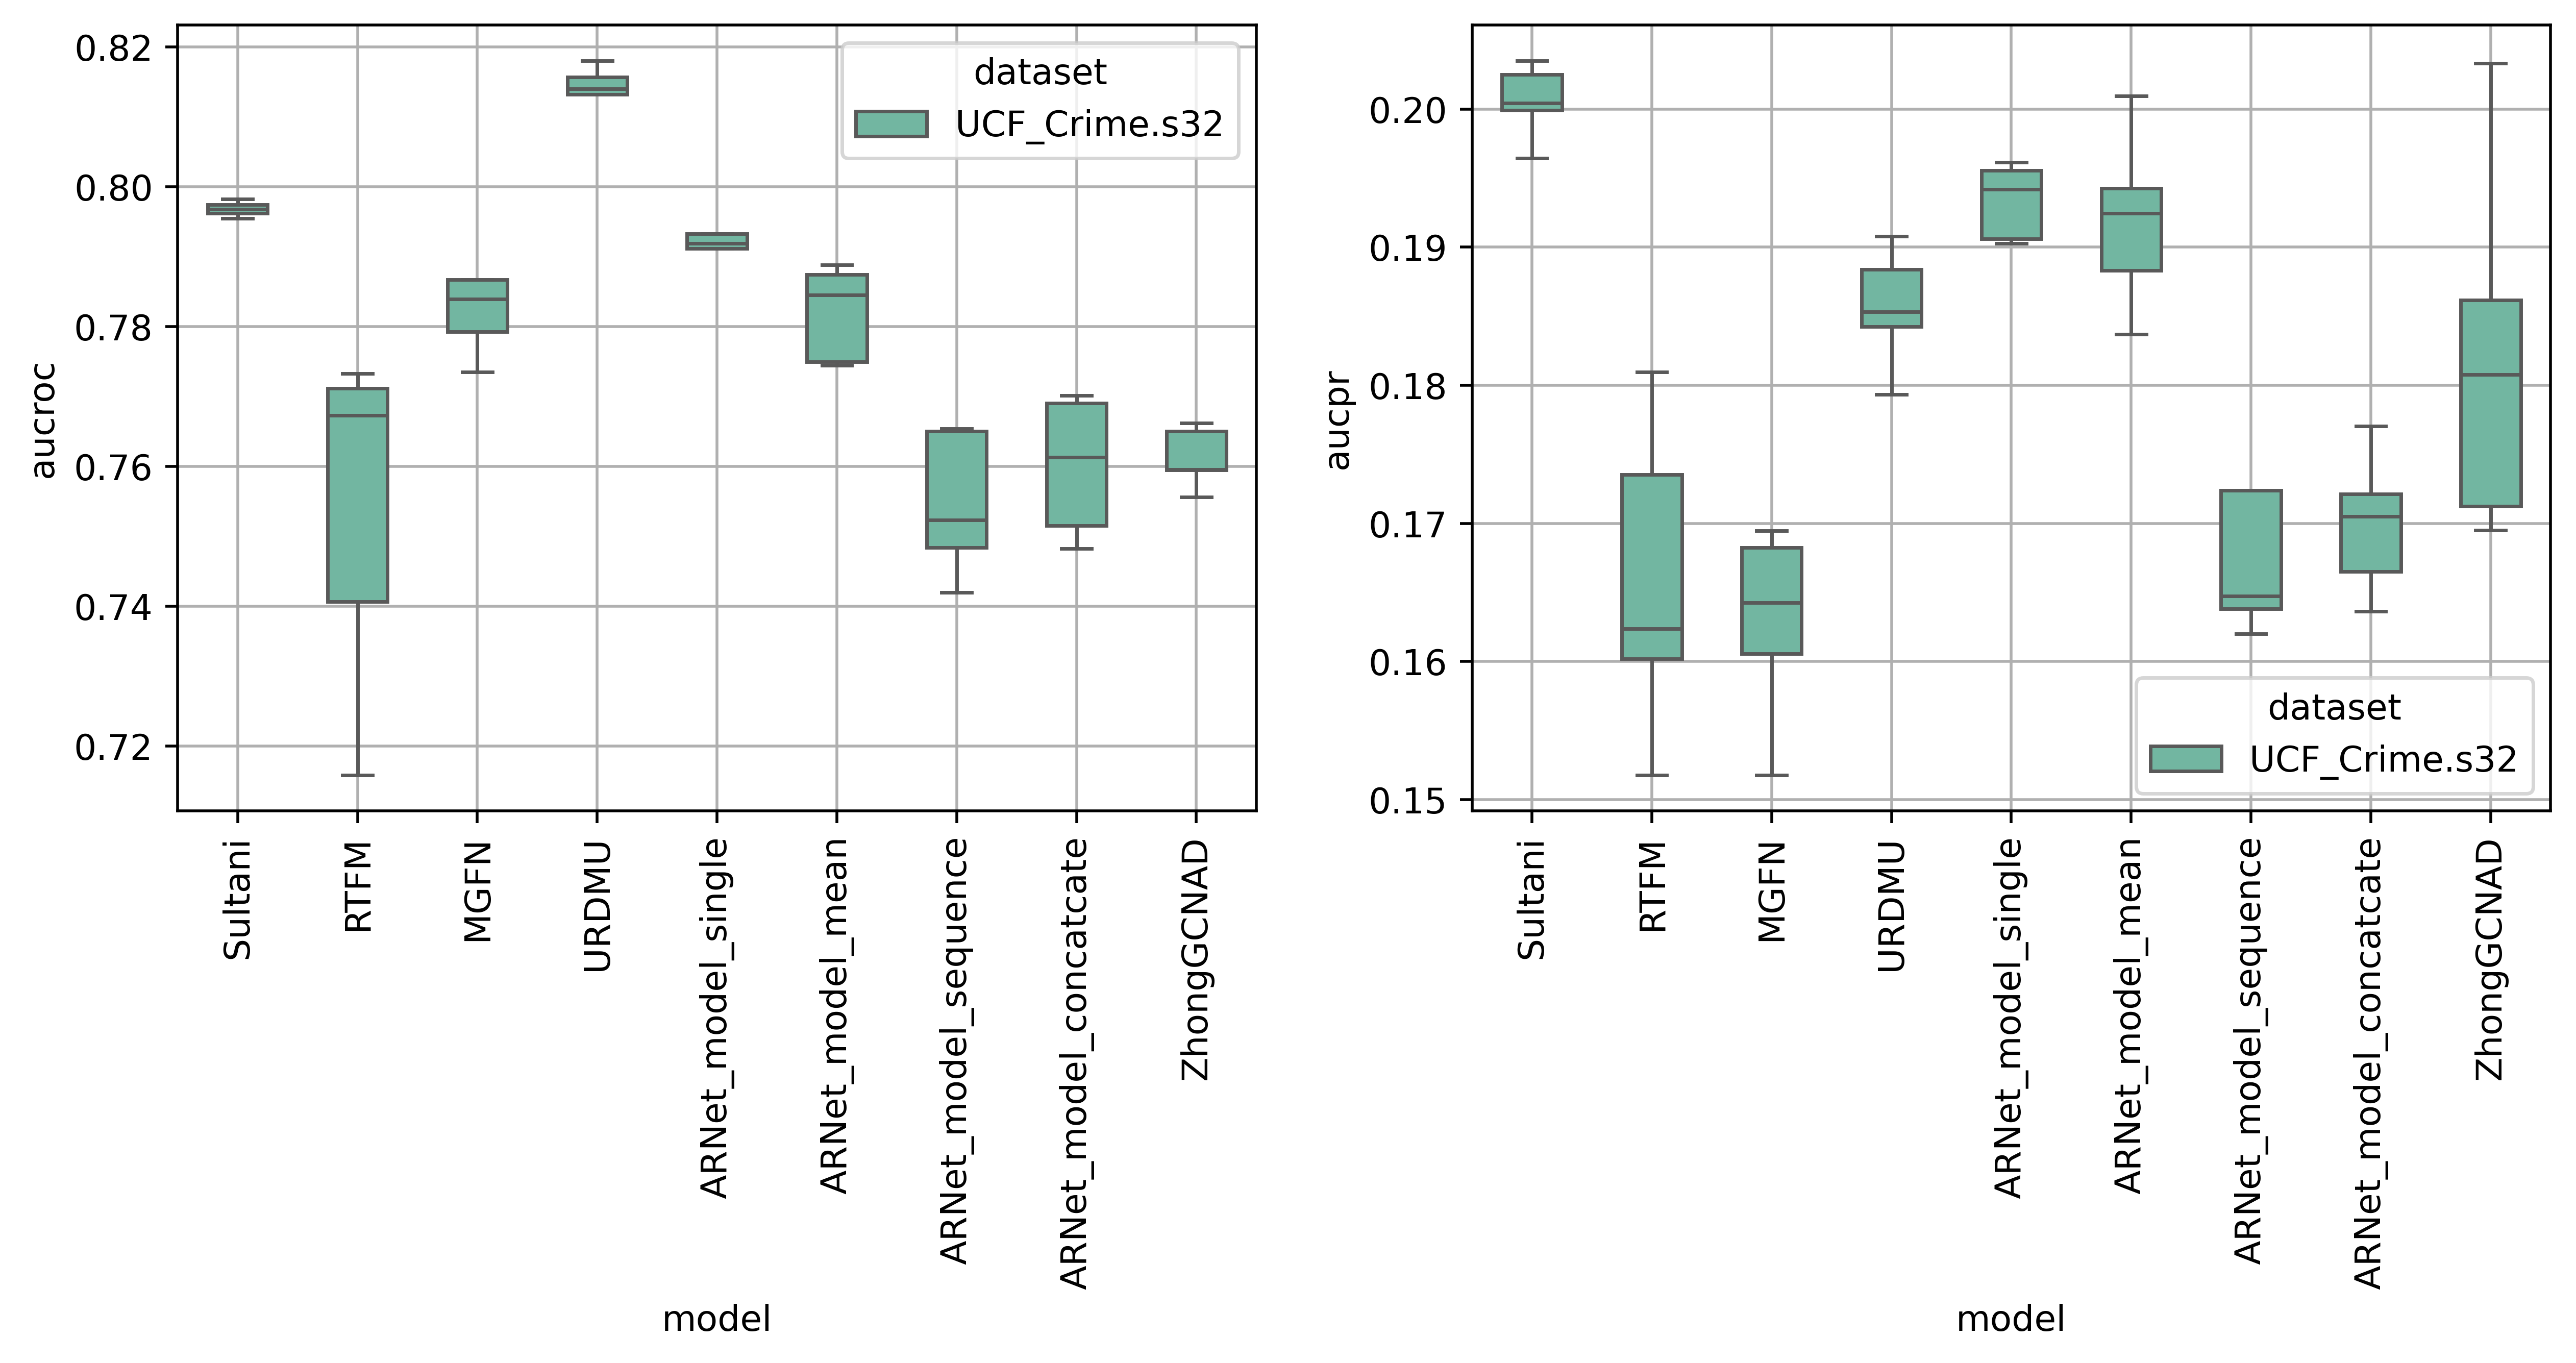

In [10]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt



video_detail = pd.read_excel("results/video/summary/summary.xlsx", sheet_name="详细结果")

method_order = ["Sultani","RTFM","MGFN","URDMU","ARNet_model_single","ARNet_model_mean","ARNet_model_sequence","ARNet_model_concatcate","ZhongGCNAD"]
hew_order = ['UCF_Crime.s32']
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=500)
ax = axes[0]
sns.boxplot(
    data=video_detail,
    x="model",
    y="aucroc",
    hue="dataset",
    palette="Set2",
    fliersize=0,
    width=0.5,
    showfliers=False,
    ax=ax,
    order=method_order,
    hue_order=hew_order,
)
ax.grid()
ax.tick_params(axis='x', rotation=90)

ax = axes[1]
sns.boxplot(
    data=video_detail,
    x="model",
    y="aucpr",
    hue="dataset",
    palette="Set2",
    fliersize=0,
    width=0.5,
    showfliers=False,
    ax=ax,
    order=method_order,
    hue_order=hew_order,
)

ax.grid()
ax.tick_params(axis='x', rotation=90)
